In [ ]:
!pip install pogema
!pip install torch
!pip install gymnasium
!pip install stable-baselines3
!pip install wandb
!pip uninstall pogema -y
!pip install --upgrade pogema

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 35.8 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.28.1
    Uninstalling gymnasium-0.28.1:
      Successfully uninstalled gymnasium-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pogema 1.4.0 requires gymnasium==0.28.1, but you have gymnasium 1.2.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 70.1 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.4
    Uninstalling pydantic_core-2.41.4:
      Successfully uninstalled pyd

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from pogema import pogema_v0
from pogema import GridConfig

In [ ]:
import torch
import torch.nn as nn

class CommTransformerNet(nn.Module):
    def __init__(self, obs_shape=(3, 11, 11), n_actions=5, seq_len=10, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim

        # 1. LOCAL FEATURE EXTRACTOR (CNN)
        # We use a slightly deeper CNN to capture better spatial features for larger maps
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(obs_shape[0], 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2), # 11x11 -> 5x5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.Flatten()
        )

        # 2. PROJECTION LAYER
        # Fuses CNN features (1600) + Goal Vector (2) into Embedding Space
        self.projection = nn.Linear(64 * 5 * 5 + 2, embed_dim)

        # 3. MULTI-HEAD SELECTIVE COMMUNICATION
        # 8 heads allow an agent to attend to 8 different 'types' of neighbor threats
        self.comm_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=8,
            dropout=0.1,  # Helps prevent 'Communication Overfitting' at high agent counts
            batch_first=True
        )

        # 4. STABILIZATION LAYERS
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)

        # Feed-Forward Network (FFN) to process the social context
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.LeakyReLU(0.1),
            nn.Linear(embed_dim * 2, embed_dim)
        )

        # 5. OUTPUT HEADS
        self.policy_head = nn.Linear(embed_dim, n_actions)
        self.value_head = nn.Linear(embed_dim, 1)

        # 6. ORTHOGONAL INITIALIZATION
        self._apply_init()

    def _apply_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=nn.init.calculate_gain('leaky_relu'))
                nn.init.constant_(m.bias, 0)
        # Policy head gain should be very small to prioritize Expert IL at the start
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)

    def forward(self, obs_seq, goal_seq):
        """
        obs_seq:  (num_agents, seq_len, 3, 11, 11)
        goal_seq: (num_agents, seq_len, 2)
        """
        num_agents, seq_len, C, H, W = obs_seq.shape

        # A. Process current state (ignore past sequence for now to save CPU)
        curr_obs = obs_seq[:, -1]
        curr_goal = goal_seq[:, -1]

        cnn_feats = self.feature_extractor(curr_obs)

        # B. Fusion & Projection
        combined = torch.cat([cnn_feats, curr_goal], dim=-1)
        x = self.projection(combined) # (num_agents, embed_dim)

        # C. Multi-Agent Communication (Transformer Encoder Layer logic)
        # Prepare for MultiheadAttention: (Batch=1, Seq=num_agents, Dim=embed_dim)
        x_in = x.unsqueeze(0)

        # 1. Self-Attention Block
        attn_out, weights = self.comm_attn(x_in, x_in, x_in)
        x_norm1 = self.layernorm1(x_in + attn_out) # Residual + Norm

        # 2. Feed-Forward Block (Deepens the "social understanding")
        ffn_out = self.ffn(x_norm1)
        x_context = self.layernorm2(x_norm1 + ffn_out).squeeze(0) # Residual + Norm

        # D. Final Predictions
        logits = self.policy_head(x_context)
        values = self.value_head(x_context)

        return logits, values, weights

In [ ]:
import pogema
from pogema import GridConfig

def create_env(config_dict):
    """
    config_dict: {
        "num_agents": int,
        "size": int,
        "density": float,
        "obs_radius": 5  # Standard for PRIMAL (11x11 window)
    }
    """
    # 1. Define the internal Grid configuration
    grid_cfg = GridConfig(
        num_agents=config_dict["num_agents"],
        size=config_dict["size"],
        density=config_dict["density"],
        obs_radius=5,      # This yields a (2*radius + 1) = 11x11 observation
        seed=None,         # Set a seed here for reproducible evaluation
        max_episode_steps=config_dict["max_episode_steps"] # Prevents infinite loops in hard levels
    )

    # 2. Create the environment
    # 'pogema-v0' is the standard non-adversarial MAPF task
    env = pogema.pogema_v0(grid_config=grid_cfg)

    return env

In [ ]:
class CurriculumManager:
    def __init__(self):
        self.level = 1
        self.config_map = {
            1: {"num_agents": 1, "size": 8,  "density": 0.0, "max_episode_steps": 256},
            2: {"num_agents": 2, "size": 12, "density": 0.0, "max_episode_steps": 128},
            3: {"num_agents": 4, "size": 16, "density": 0.0, "max_episode_steps": 128},
            4: {"num_agents": 8, "size": 24, "density": 0.0, "max_episode_steps": 256},
            5: {"num_agents": 16,"size": 32, "density": 0.0, "max_episode_steps": 256},
            6: {"num_agents": 32,"size": 64, "density": 0.0, "max_episode_steps": 256},
            # 7: {"num_agents": 64,"size": 256, "density": 0.0, "max_episode_steps": 2048},
            # 8: {"num_agents": 128,"size": 512, "density": 0.0, "max_episode_steps": 2048},
            7: {"num_agents": 2,"size": 8, "density": 0.1, "max_episode_steps": 256},
            8: {"num_agents": 4,"size": 16, "density": 0.1, "max_episode_steps": 256},
            9: {"num_agents": 8,"size": 24, "density": 0.1, "max_episode_steps": 256},
            # 10: {"num_agents": 16,"size": 256, "density": 0.1, "max_episode_steps": 2048},
            10: {"num_agents": 2,"size": 12, "density": 0.2, "max_episode_steps": 256},
            11: {"num_agents": 4,"size": 16, "density": 0.2, "max_episode_steps": 256},
            12: {"num_agents": 8,"size": 24, "density": 0.2, "max_episode_steps": 256},
            13: {"num_agents": 2,"size": 12, "density": 0.3, "max_episode_steps": 256},
          }

    def update(self, success_rate):
        if success_rate >= 80 and self.level < 13:
            self.level += 1
            print(f"Level Up! Now at Level {self.level}")
            return True
        return False

In [ ]:
def run_marl_evaluation(model, env, num_episodes=10, device='cpu'):
    model.eval()
    total_rewards = []
    total_lengths = []
    successes = 0

    for _ in range(num_episodes):
        obs, _ = env.reset()
        active_cfg = env.unwrapped.grid_config
        num_agents = active_cfg.num_agents

        obs_buf = torch.zeros((num_agents, 10, 3, 11, 11), device=device)
        goal_buf = torch.zeros((num_agents, 10, 2), device=device)

        ep_ret = 0
        ep_len = 0

        for step in range(active_cfg.max_episode_steps):
            gv = get_goal_vec(env.unwrapped, active_cfg)
            obs_t = torch.tensor(np.array(obs), dtype=torch.float32).to(device)

            obs_buf = torch.roll(obs_buf, shifts=-1, dims=1); obs_buf[:, -1] = obs_t
            goal_buf = torch.roll(goal_buf, shifts=-1, dims=1); goal_buf[:, -1] = gv

            with torch.no_grad():
                logits, _, _ = model(obs_buf, goal_buf)
                action = torch.argmax(logits, dim=-1) # Greedy for eval

            obs, rewards, terminated, truncated, _ = env.step(action.cpu().numpy())
            ep_ret += np.mean(rewards) # Average reward across all agents this step
            ep_len += 1

            if all(terminated):
                successes += 1
                break
            if any(truncated): break

        total_rewards.append(ep_ret)
        total_lengths.append(ep_len)

    model.train()
    return np.mean(total_rewards), np.mean(total_lengths), (successes/num_episodes)*100

In [ ]:
import heapq

def get_space_time_astar(grid, start, goal, reserved, max_t=30):
    """
    grid: 2D array (True for obstacle)
    reserved: set of (x, y, t) occupied by higher priority agents
    """
    rows, cols = len(grid), len(grid[0])
    # moves: Stay, Up, Down, Left, Right
    moves = [(0, 0), (-1, 0), (1, 0), (0, -1), (0, 1)]

    # pq: (f_score, t, x, y)
    start_state = (0 + abs(start[0]-goal[0]) + abs(start[1]-goal[1]), 0, start[0], start[1])
    pq = [start_state]

    came_from = {}
    g_score = {(start[0], start[1], 0): 0}

    while pq:
        f, t, x, y = heapq.heappop(pq)

        if (x, y) == goal or t >= max_t:
            # Reconstruct path
            path = []
            curr = (x, y, t)
            while curr in came_from:
                path.append((curr[0], curr[1]))
                curr = came_from[curr]
            path.append(start)
            return path[::-1]

        for i, (dx, dy) in enumerate(moves):
            nx, ny, nt = x + dx, y + dy, t + 1

            if 0 <= nx < rows and 0 <= ny < cols and not grid[nx][ny]:
                # Check Vertex Conflict (Is someone here at this time?)
                if (nx, ny, nt) in reserved: continue

                # Check Edge Conflict (Did we swap places with someone?)
                if (nx, ny, t) in reserved and (x, y, nt) in reserved: continue

                if (nx, ny, nt) not in g_score or g_score[(nx, ny, nt)] > nt:
                    g_score[(nx, ny, nt)] = nt
                    h = abs(nx-goal[0]) + abs(ny-goal[1])
                    heapq.heappush(pq, (nt + h, nt, nx, ny))
                    came_from[(nx, ny, nt)] = (x, y, t)

    return [(start[0], start[1])] * 2 # Fallback: Stay put

In [ ]:
# --- PBS Expert Logic ---
def get_pbs_expert_actions(env):
    core_env = env.unwrapped
    grid = core_env.grid.get_obstacles()
    agents_xy = core_env.get_agents_xy()
    targets_xy = core_env.get_targets_xy()

    num_agents = len(agents_xy)
    reserved = set()
    expert_actions = []

    for i in range(num_agents):
        start = agents_xy[i]
        goal = targets_xy[i]

        # Space-Time A* (must be defined in your namespace)
        path = get_space_time_astar(grid, start, goal, reserved)

        if len(path) > 1:
            next_step = path[1]
            dx, dy = next_step[0] - start[0], next_step[1] - start[1]
            action_map = {(0,0):0, (-1,0):1, (1,0):2, (0,-1):3, (0,1):4}
            expert_actions.append(action_map.get((dx, dy), 0))
        else:
            expert_actions.append(0)

        for t, (px, py) in enumerate(path):
            reserved.add((px, py, t))
            if (px, py) == goal:
                for future_t in range(t, 31): # Goal persistence
                    reserved.add((px, py, future_t))
    return expert_actions

In [ ]:
def get_goal_vec(env, current_cfg):
    agents = np.array(env.get_agents_xy())
    targets = np.array(env.get_targets_xy())

    # POGEMA GridConfig uses attributes, not dictionary keys
    # Access .size instead of ["size"]
    grid_size = current_cfg.size

    vec = (targets - agents) / grid_size
    return torch.tensor(vec, dtype=torch.float32).to(device)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION & HYPERPARAMETERS ---
EPISODES = 20000
GAMMA = 0.99
ENTROPY_COEFF = 0.05  # A2C exploration bonus factor
LR = 1e-4
SEQ_LEN = 10
IL_COEFF = 0.5        # Weight for the PBS Imitation Learning loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CommTransformerNet(obs_shape=(3, 11, 11), n_actions=5, seq_len=SEQ_LEN).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Keeping your CurriculumManager intact without structural modification
curriculum = CurriculumManager()
env = create_env(curriculum.config_map[curriculum.level])

def get_dist(pogema_env):
    """Calculates Manhattan distance for all agents."""
    agents = pogema_env.get_agents_xy()
    targets = pogema_env.get_targets_xy()
    return [abs(a[0]-t[0]) + abs(a[1]-t[1]) for a, t in zip(agents, targets)]

history = {
    "episodes": [],
    "success_rate": [],
    "loss": [],
    "level": [],
    "eval_returns": [],
    "eval_lengths": []
}

print(f"--- Training Transformer via A2C: Collision Penalties, Team Rewards & PBS Guidance Enabled ---")

for episode in range(EPISODES):
    # --- ROLLOUT PHASE ---
    obs, _ = env.reset()
    active_cfg = env.unwrapped.grid_config
    num_agents = active_cfg.num_agents

    # Temporal sequence windows tracked across iterations
    obs_buf = torch.zeros((num_agents, SEQ_LEN, 3, 11, 11), device=device)
    goal_buf = torch.zeros((num_agents, SEQ_LEN, 2), device=device)

    # Dynamic step tracking memory for on-policy update
    ep_obs_sequences, ep_goal_sequences = [], []
    ep_actions, ep_expert_actions = [], []
    ep_rewards, ep_masks = [], []

    prev_positions = np.array(env.unwrapped.get_agents_xy())

    for step in range(active_cfg.max_episode_steps):
        gv = get_goal_vec(env.unwrapped, active_cfg)
        obs_t = torch.tensor(np.array(obs), dtype=torch.float32).to(device)

        obs_buf = torch.roll(obs_buf, shifts=-1, dims=1); obs_buf[:, -1] = obs_t
        goal_buf = torch.roll(goal_buf, shifts=-1, dims=1); goal_buf[:, -1] = gv

        # 1. Query the PBS Space-Time Expert for guidance targets
        expert_acts = get_pbs_expert_actions(env)

        # Collection occurs without grad tracking to keep rollout memory lightweight
        with torch.no_grad():
            logits, val, _ = model(obs_buf, goal_buf)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()

        # Environment Step
        d_before = get_dist(env.unwrapped)
        next_obs, base_rewards, terminated, truncated, _ = env.step(action.cpu().numpy())
        d_after = get_dist(env.unwrapped)
        curr_positions = np.array(env.unwrapped.get_agents_xy())

        # --- ADVANCED MARL REWARD SHAPING ---
        shaped_rewards = np.zeros(num_agents, dtype=np.float32)
        finished_this_step = sum(1 for r in base_rewards if r > 0.5)

        for i in range(num_agents):
            # 1. Individual Goal Success
            if base_rewards[i] > 0.5:
                shaped_rewards[i] += 2.0
            else:
                # 3. Collision/Stagnation Penalty
                if action[i] > 0 and np.array_equal(curr_positions[i], prev_positions[i]):
                    shaped_rewards[i] -= 0.05

        # Save structural tensors containing full temporal sequence history matrices
        ep_obs_sequences.append(obs_buf.clone())
        ep_goal_sequences.append(goal_buf.clone())
        ep_actions.append(action)
        ep_expert_actions.append(torch.tensor(expert_acts, dtype=torch.long, device=device))
        ep_rewards.append(torch.tensor(shaped_rewards, device=device))
        ep_masks.append(torch.tensor(1.0 - np.array(terminated, dtype=np.float32), device=device))

        obs = next_obs
        prev_positions = curr_positions
        if all(terminated) or any(truncated):
            break

    # --- 2. A2C UPDATE PHASE ---
    rollout_len = len(ep_actions)
    if rollout_len < 2:
        continue

    # Flatten lists into sequence-wide tensor matrices
    b_obs = torch.cat(ep_obs_sequences, dim=0)          # Shape: (rollout_len * num_agents, SEQ_LEN, 3, 11, 11)
    b_goals = torch.cat(ep_goal_sequences, dim=0)        # Shape: (rollout_len * num_agents, SEQ_LEN, 2)
    b_actions = torch.cat(ep_actions, dim=0)            # Shape: (rollout_len * num_agents)
    b_expert_actions = torch.cat(ep_expert_actions, dim=0)  # Shape: (rollout_len * num_agents)

    # Calculate Value Returns (Targets via Monte Carlo Bellman tracking)
    returns = []
    G = torch.zeros(num_agents, device=device)
    for r, m in zip(reversed(ep_rewards), reversed(ep_masks)):
        G = r + GAMMA * G * m
        returns.insert(0, G.clone())
    b_returns = torch.cat(returns).detach()             # Shape: (rollout_len * num_agents)

    # Forward pass to create structural computational graph tracking
    new_logits, new_values, _ = model(b_obs, b_goals)
    new_values = new_values.flatten()

    # Calculate Action Probability Distributions
    new_dist = torch.distributions.Categorical(logits=new_logits)
    new_log_probs = new_dist.log_prob(b_actions)

    # Calculate Advantages (targets - values)
    b_advantages = (b_returns - new_values).detach()
    b_advantages = (b_advantages - b_advantages.mean()) / (b_advantages.std() + 1e-8)

    # Standard A2C Loss Components (Single Optimization Step, No Clipping)
    actor_loss = -(new_log_probs * b_advantages).mean()
    critic_loss = F.mse_loss(new_values, b_returns)
    entropy_loss = new_dist.entropy().mean()

    # PBS Expert Guidance Regularization Loss (Cross-Entropy)
    il_loss = F.cross_entropy(new_logits, b_expert_actions)

    # Combined Loss Equation
    total_loss = actor_loss + 0.5 * critic_loss - ENTROPY_COEFF * entropy_loss + IL_COEFF * il_loss

    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
    optimizer.step()

    # --- 3. LOGGING & EVALUATION ---
    if episode % 100 == 0:
        avg_ret, avg_len, sr = run_marl_evaluation(model, env, num_episodes=10, device=device)

        history["episodes"].append(episode)
        history["success_rate"].append(sr)
        history["loss"].append(total_loss.item())
        history["level"].append(curriculum.level)
        history["eval_returns"].append(avg_ret)
        history["eval_lengths"].append(avg_len)

        print(f"Ep {episode:04d} | SR: {sr:>3.1f}% | Loss: {history['loss'][-1]:.4f} | Lvl: {curriculum.level}")

        if curriculum.update(sr):
            env = create_env(curriculum.config_map[curriculum.level])

--- 🚀 Training Transformer via A2C: Collision Penalties, Team Rewards & PBS Guidance Enabled ---
Ep 0000 | SR: 0.0% | Loss: 1.1362 | Lvl: 1
Ep 0100 | SR: 20.0% | Loss: 0.9129 | Lvl: 1
Ep 0200 | SR: 0.0% | Loss: 0.6231 | Lvl: 1
Ep 0300 | SR: 10.0% | Loss: 0.7805 | Lvl: 1
Ep 0400 | SR: 20.0% | Loss: 0.7610 | Lvl: 1
Ep 0500 | SR: 0.0% | Loss: 0.5781 | Lvl: 1
Ep 0600 | SR: 10.0% | Loss: 0.6452 | Lvl: 1
Ep 0700 | SR: 20.0% | Loss: 0.0193 | Lvl: 1
Ep 0800 | SR: 80.0% | Loss: 0.1789 | Lvl: 1
Level Up! Now at Level 2
Ep 0900 | SR: 70.0% | Loss: 0.4283 | Lvl: 2
Ep 1000 | SR: 100.0% | Loss: -0.0844 | Lvl: 2
Level Up! Now at Level 3
Ep 1100 | SR: 100.0% | Loss: 0.1613 | Lvl: 3
Level Up! Now at Level 4
Ep 1200 | SR: 70.0% | Loss: 0.2352 | Lvl: 4
Ep 1300 | SR: 70.0% | Loss: 0.0026 | Lvl: 4
Ep 1400 | SR: 80.0% | Loss: 0.0832 | Lvl: 4
Level Up! Now at Level 5
Ep 1500 | SR: 20.0% | Loss: 0.0387 | Lvl: 5
Ep 1600 | SR: 30.0% | Loss: -0.0135 | Lvl: 5
Ep 1700 | SR: 20.0% | Loss: 0.0243 | Lvl: 5
Ep 1800 | 

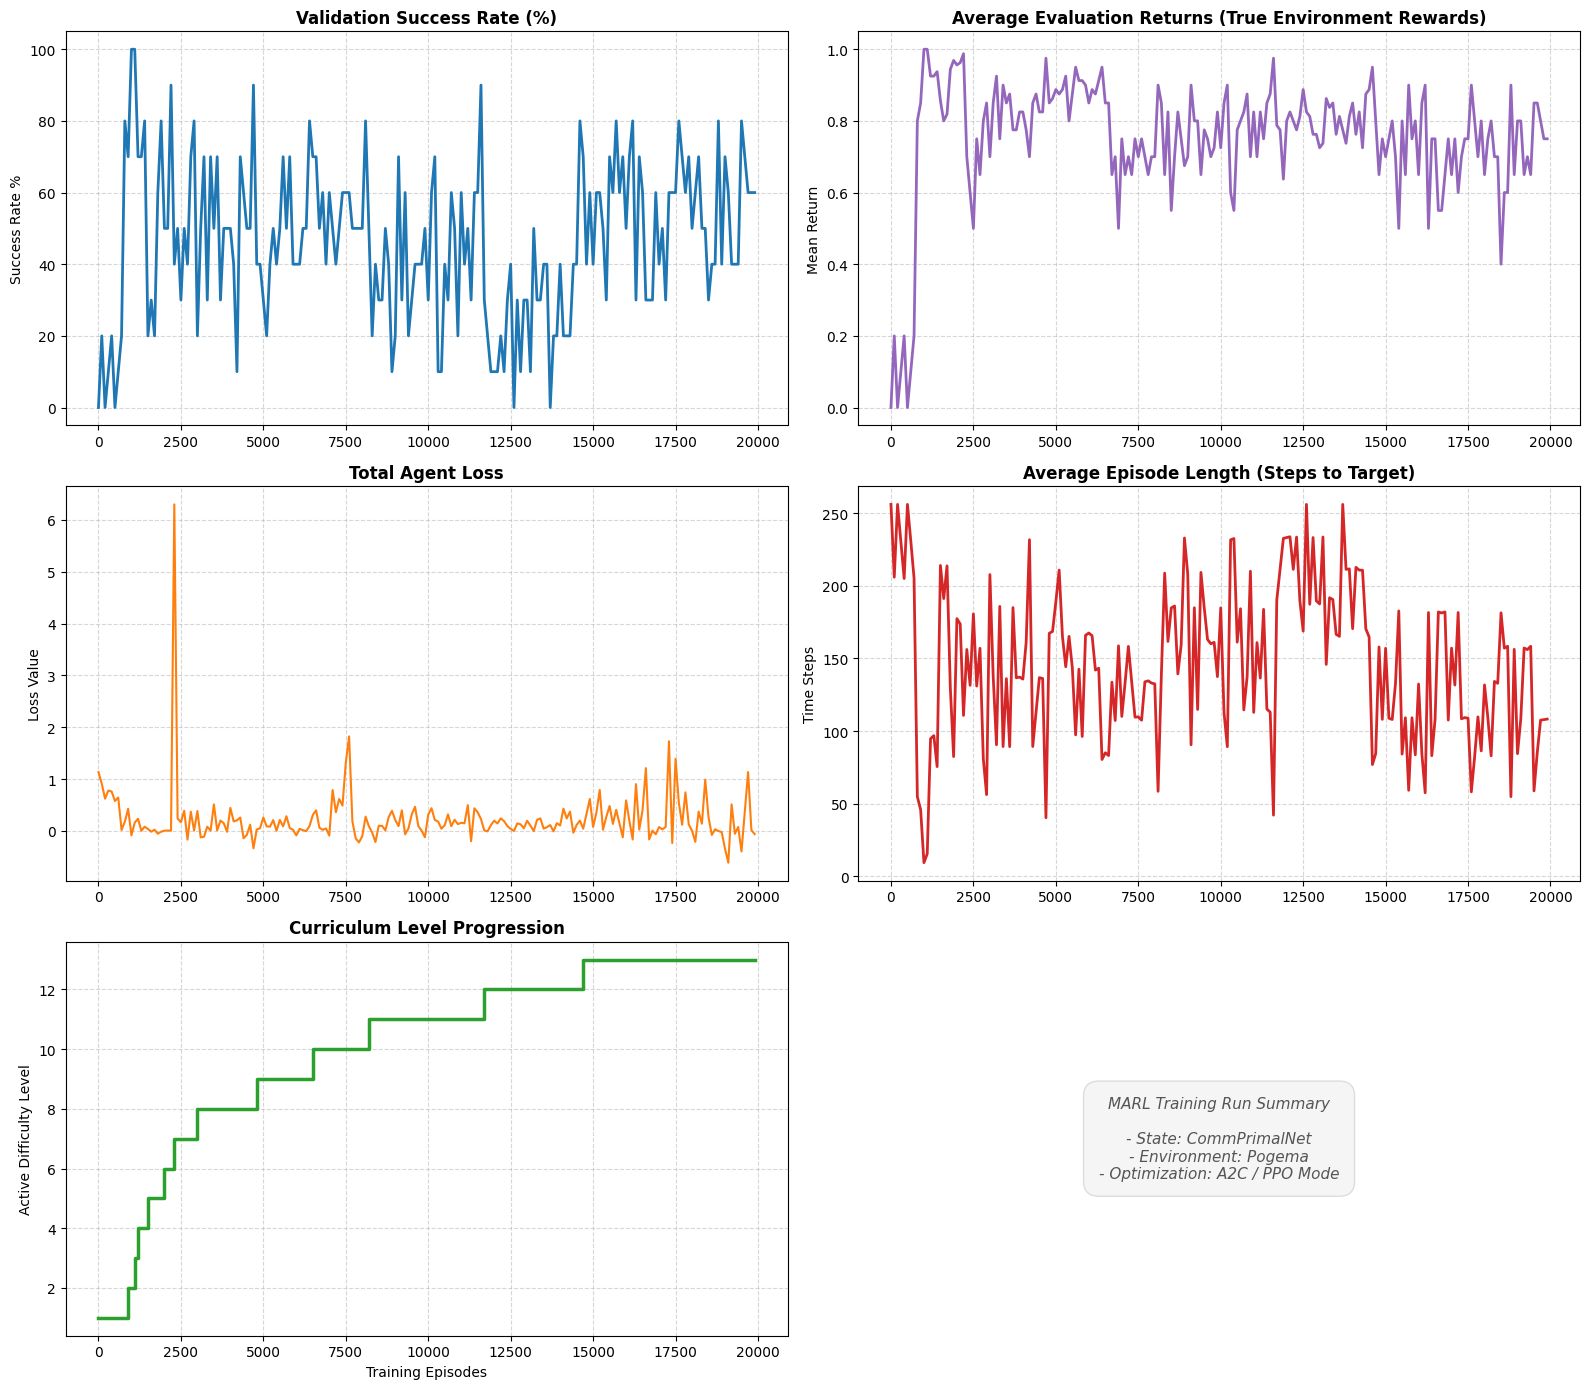

In [ ]:
import matplotlib.pyplot as plt

def plot_comprehensive_marl_results(history):
    """
    Consolidated MARL Visualization Dashboard.
    Includes fallback protection to avoid crashes if keys are empty.
    """
    if not history.get("episodes"):
        print("⚠️ Warning: No episode data found in history dictionary to plot.")
        return

    fig, axs = plt.subplots(3, 2, figsize=(16, 14))
    episodes = history["episodes"]

    # ----------------------------------------------------
    # COLUMN 1: TRAINING METRICS (Left)
    # ----------------------------------------------------
    # Panel 1: Success Rate (%) - handles both "success_rate" or "sr" keys
    sr_key = "success_rate" if "success_rate" in history else "sr"
    if history.get(sr_key):
        axs[0, 0].plot(episodes, history[sr_key], color='#1f77b4', linewidth=2)
    axs[0, 0].set_title("Validation Success Rate (%)", fontsize=12, fontweight='bold')
    axs[0, 0].set_ylabel("Success Rate %", fontsize=10)
    axs[0, 0].grid(True, linestyle='--', alpha=0.5)

    # Panel 2: Total Loss
    if history.get("loss"):
        axs[1, 0].plot(episodes, history["loss"], color='#ff7f0e', linewidth=1.5)
    axs[1, 0].set_title("Total Agent Loss", fontsize=12, fontweight='bold')
    axs[1, 0].set_ylabel("Loss Value", fontsize=10)
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)

    # Panel 3: Curriculum Stage Steps
    if history.get("level"):
        axs[2, 0].step(episodes, history["level"], where='post', color='#2ca02c', linewidth=2.5)
    axs[2, 0].set_title("Curriculum Level Progression", fontsize=12, fontweight='bold')
    axs[2, 0].set_xlabel("Training Episodes", fontsize=10)
    axs[2, 0].set_ylabel("Active Difficulty Level", fontsize=10)
    axs[2, 0].grid(True, linestyle='--', alpha=0.5)

    # ----------------------------------------------------
    # COLUMN 2: EVALUATION PERFORMANCES (Right)
    # ----------------------------------------------------
    # Panel 4: Average Raw Target Returns
    if history.get("eval_returns"):
        axs[0, 1].plot(episodes, history["eval_returns"], color='#9467bd', linewidth=2)
    axs[0, 1].set_title("Average Evaluation Returns (True Environment Rewards)", fontsize=12, fontweight='bold')
    axs[0, 1].set_ylabel("Mean Return", fontsize=10)
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)

    # Panel 5: Mean Temporal Execution Steps
    if history.get("eval_lengths"):
        axs[1, 1].plot(episodes, history["eval_lengths"], color='#d62728', linewidth=2)
    axs[1, 1].set_title("Average Episode Length (Steps to Target)", fontsize=12, fontweight='bold')
    axs[1, 1].set_ylabel("Time Steps", fontsize=10)
    axs[1, 1].grid(True, linestyle='--', alpha=0.5)

    # Panel 6: Information Text Block
    axs[2, 1].axis('off')
    axs[2, 1].text(0.5, 0.5, "MARL Training Run Summary\n\n- State: CommPrimalNet\n- Environment: Pogema\n- Optimization: A2C / PPO Mode",
                  transform=axs[2, 1].transAxes, ha='center', va='center',
                  fontsize=11, fontstyle='italic', color='#555555',
                  bbox=dict(boxstyle="round,pad=1", facecolor="#f5f5f5", edgecolor="#dddddd"))

    plt.tight_layout()
    plt.show()

plot_comprehensive_marl_results(history)